# Anomaly Detection in Network Traffic Using Supervised Machine Learning


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## 2. Load Dataset

In [ ]:
import os


_possible_train = [
    'UNSW_NB15_training-set.csv',
    '/Users//Desktop/Organized Files/07 - Excel and Data Files/UNSW_NB15_training-set(in).csv',
]
_possible_test = [
    'UNSW_NB15_testing-set.csv',
    '/Users//Desktop/Organized Files/07 - Excel and Data Files/UNSW_NB15_testing-set(in).csv',
]

train_path = next((p for p in _possible_train if os.path.exists(p)), None)
test_path  = next((p for p in _possible_test  if os.path.exists(p)), None)

if train_path is None or test_path is None:
    raise FileNotFoundError(
        'UNSW-NB15 dataset CSVs not found. '
        'Download from https://research.unsw.edu.au/projects/unsw-nb15-dataset '
        'and place them in the same folder as this notebook, or update the paths above.'
    )

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print('Training set shape:', train_df.shape)
print('Testing set shape :', test_df.shape)


Training set shape: (175341, 45)
Testing set shape : (82332, 45)


## 3. Dataset Overview

In [3]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service            175341 non-null  str    
 4   state              175341 non-null  str    
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  sinpkt       

In [5]:
train_df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


## 4. Select 5 Attack Categories and Sample Data

In [ ]:
selected_attacks = ['DoS', 'Exploits', 'Reconnaissance', 'Generic', 'Fuzzers']

attack_parts = []
for cat in selected_attacks:
    subset = train_df[train_df['attack_cat'].str.strip() == cat]
    if len(subset) > 0:
        attack_parts.append(subset.sample(min(1000, len(subset)), random_state=42))

attack_sample = pd.concat(attack_parts, ignore_index=True) if attack_parts else pd.DataFrame()

normal_sample = (
    train_df[train_df['label'] == 0]
    .sample(min(1000, (train_df['label'] == 0).sum()), random_state=42)
)

df = pd.concat([normal_sample, attack_sample], ignore_index=True)


df['attack_cat'] = df['attack_cat'].fillna('').astype(str).str.strip()
df.loc[df['label'] == 0, 'attack_cat'] = 'Normal'

df.loc[(df['attack_cat'] == '') & (df['label'] == 1), 'attack_cat'] = 'Unknown'

print('Combined dataset shape:', df.shape)
print('\nClass distribution:')
print(df['attack_cat'].value_counts())


Combined dataset shape: (6000, 45)

Class distribution:
attack_cat
Normal            1000
DoS               1000
Exploits          1000
Reconnaissance    1000
Generic           1000
Fuzzers           1000
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

### 5.1 Class Distribution

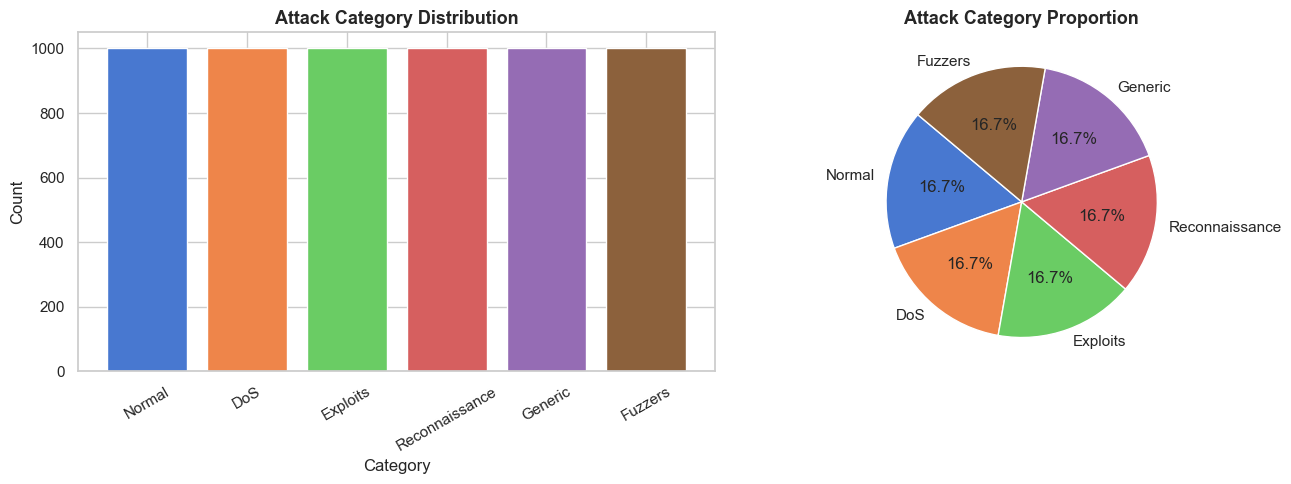

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_counts = df['attack_cat'].value_counts()
colors = sns.color_palette('muted', len(category_counts))

axes[0].bar(category_counts.index, category_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Attack Category Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
axes[1].set_title('Attack Category Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Missing Values Check

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_pct})
missing_cols = missing_summary[missing_summary['Missing Values'] > 0]

if missing_cols.empty:
    print('No missing values detected in the dataset.')
else:
    print(missing_cols)

No missing values detected in the dataset.


### 5.3 Protocol Distribution

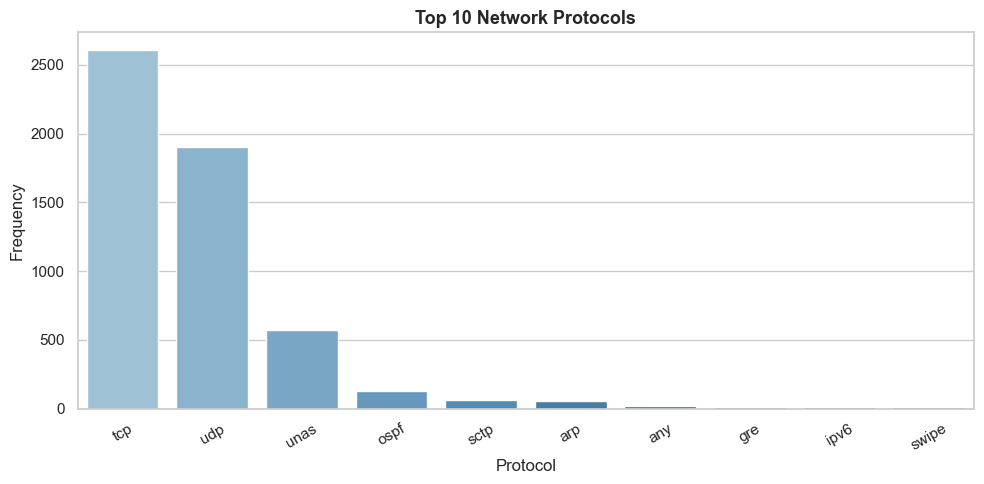

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

proto_counts = df['proto'].value_counts().head(10)
sns.barplot(x=proto_counts.index, y=proto_counts.values, palette='Blues_d', ax=ax)
ax.set_title('Top 10 Network Protocols', fontsize=13, fontweight='bold')
ax.set_xlabel('Protocol')
ax.set_ylabel('Frequency')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plot_protocol_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Feature Correlation Heatmap

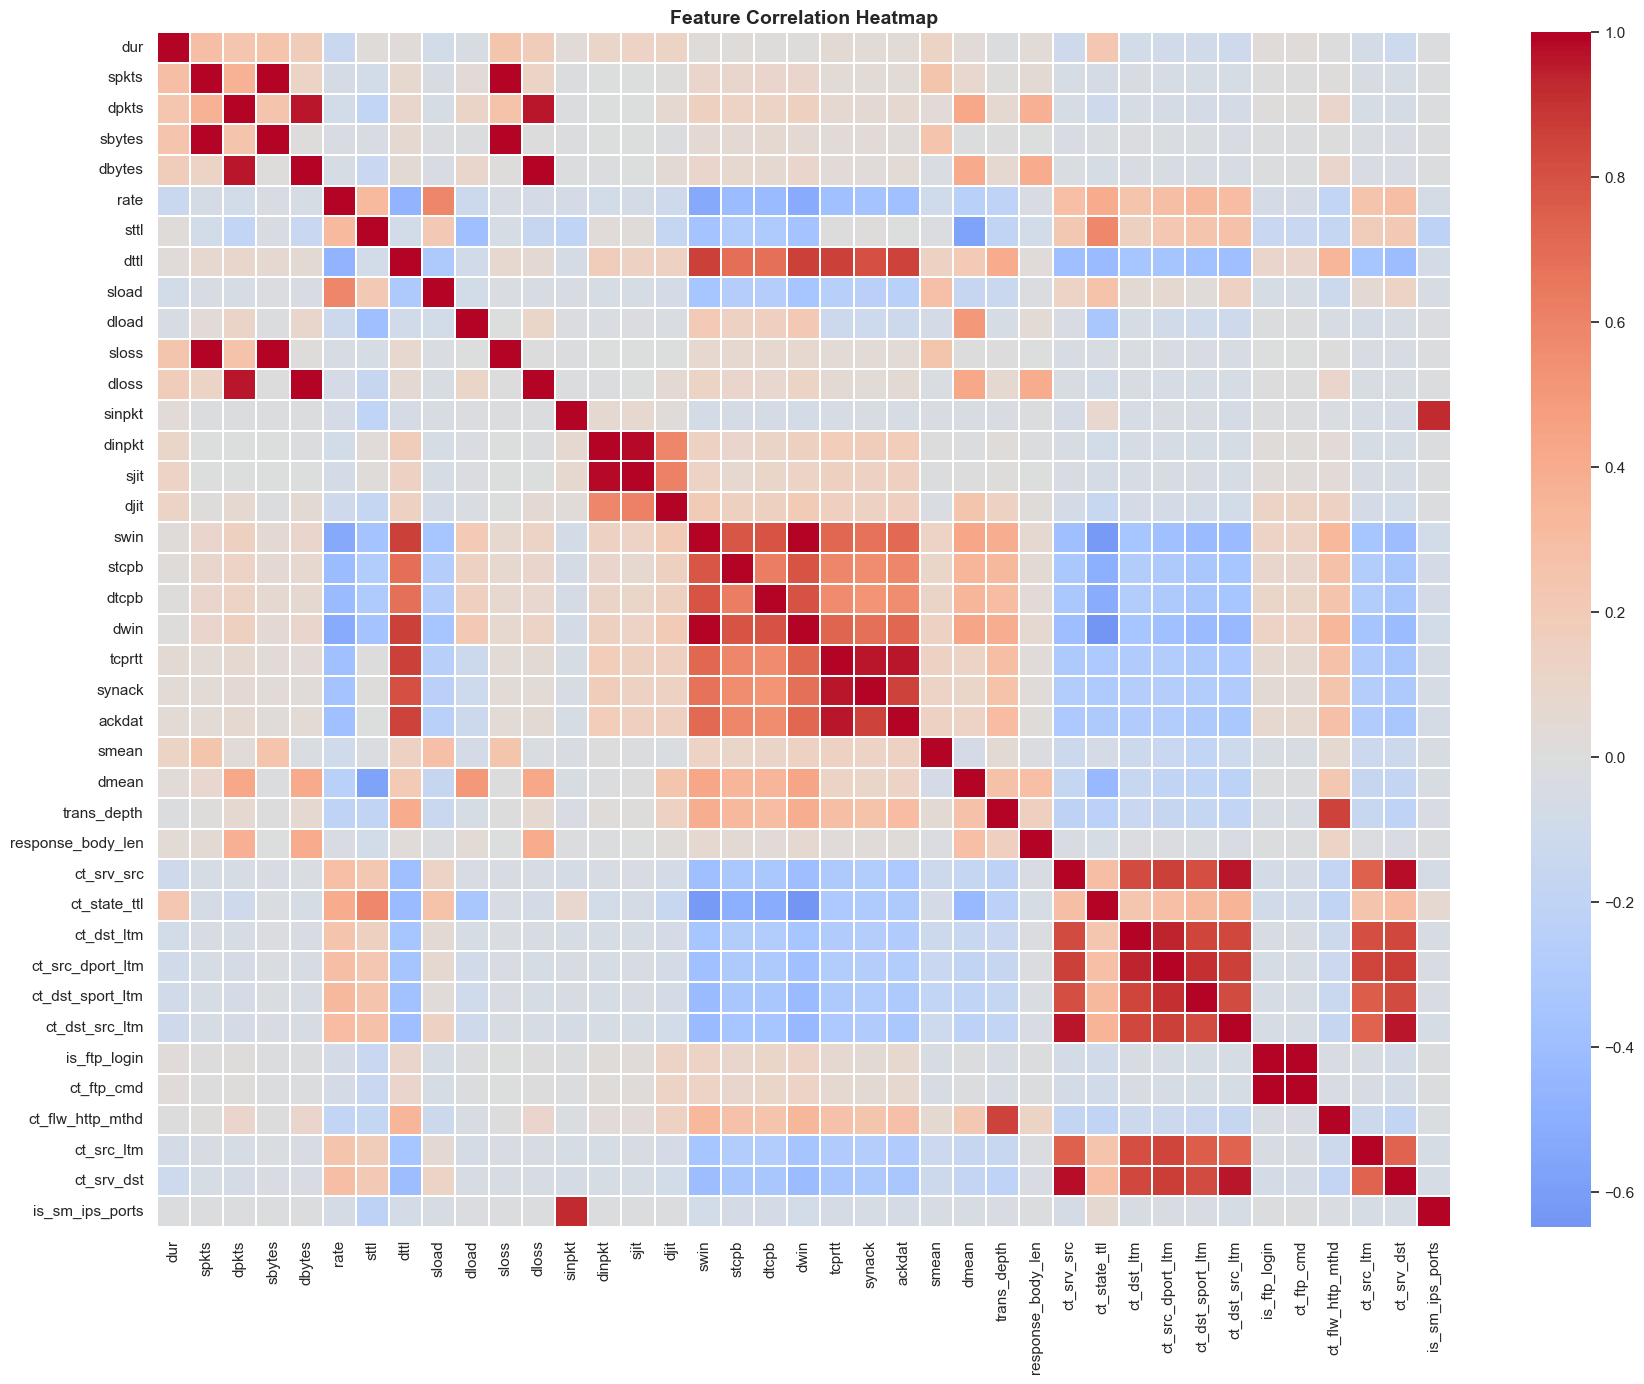

In [10]:
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['id', 'label'], errors='ignore')
corr_matrix = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    annot=False,
    ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Distribution of Key Network Features

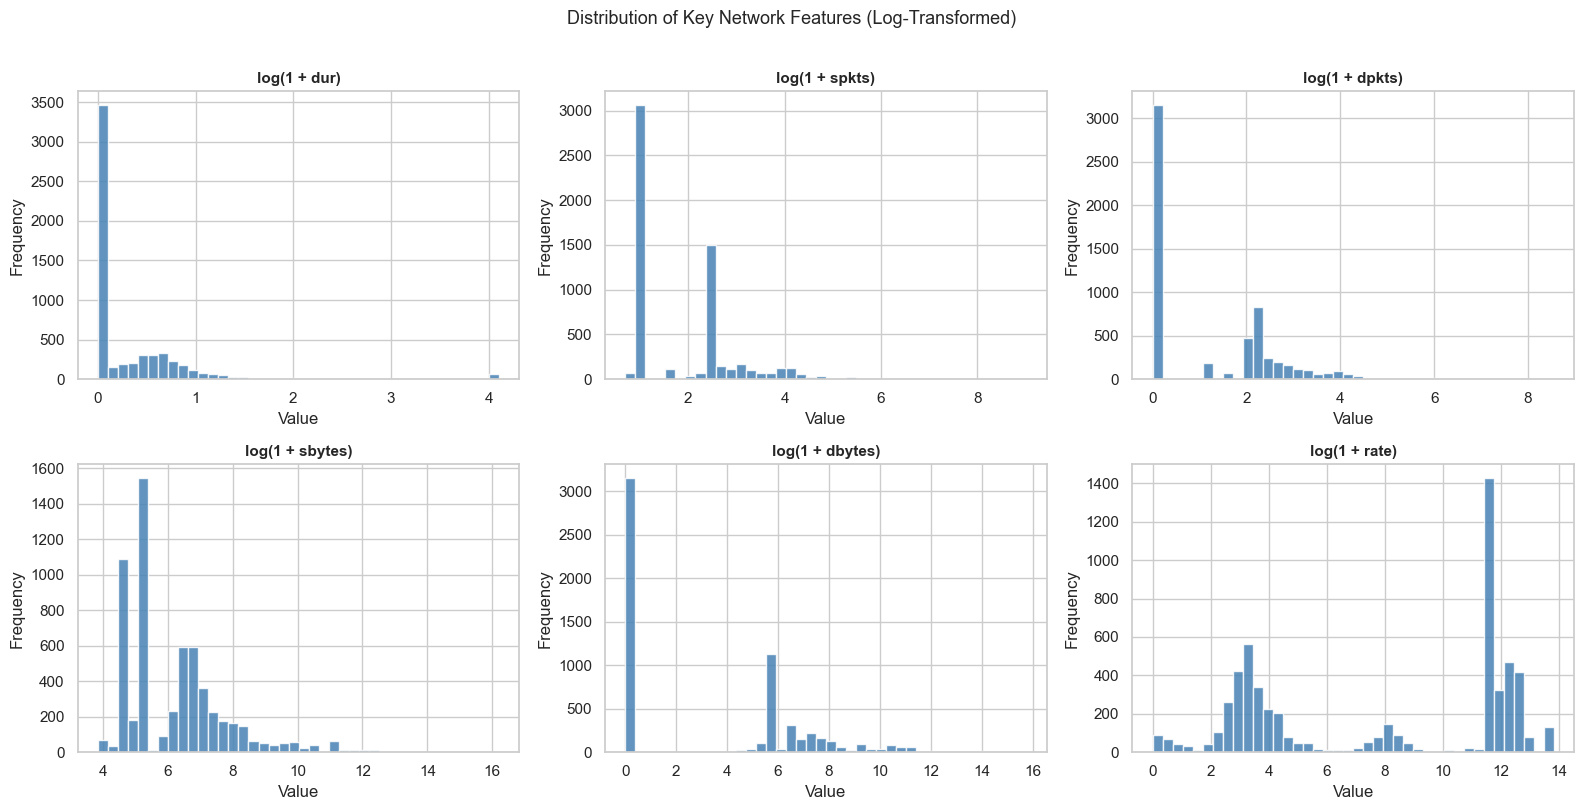

In [11]:
key_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    axes[i].hist(
        np.log1p(df[feat].clip(lower=0)),
        bins=40,
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )
    axes[i].set_title(f'log(1 + {feat})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Key Network Features (Log-Transformed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Source Bytes vs Destination Bytes by Attack Category

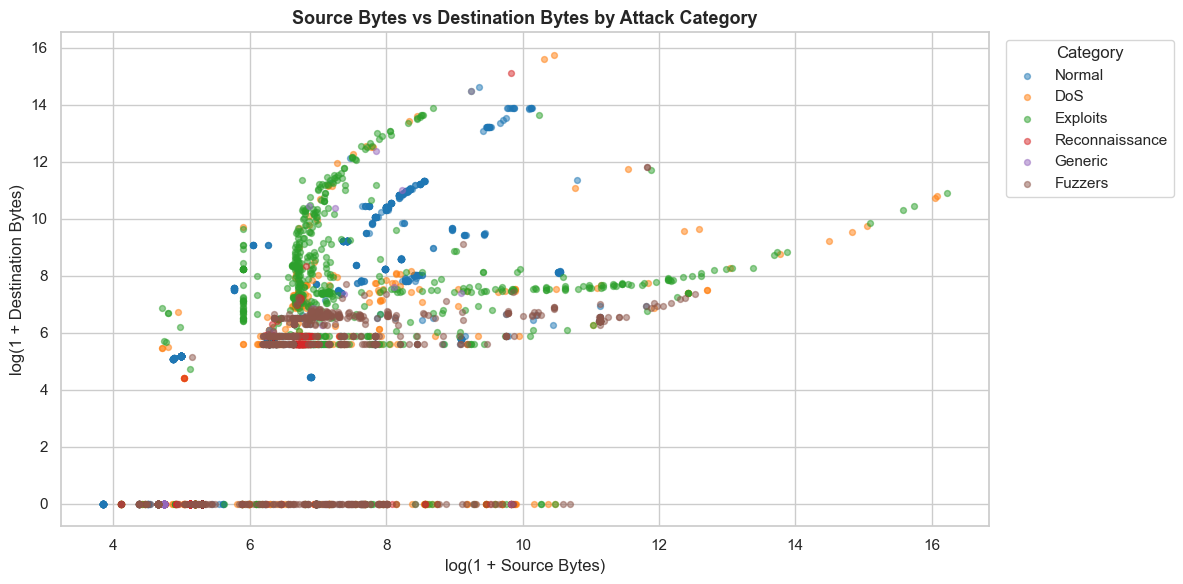

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

categories = df['attack_cat'].unique()
palette = sns.color_palette('tab10', len(categories))

for idx, cat in enumerate(categories):
    subset = df[df['attack_cat'] == cat]
    ax.scatter(
        np.log1p(subset['sbytes']),
        np.log1p(subset['dbytes']),
        label=cat,
        alpha=0.5,
        s=18,
        color=palette[idx]
    )

ax.set_title('Source Bytes vs Destination Bytes by Attack Category', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1 + Source Bytes)')
ax.set_ylabel('log(1 + Destination Bytes)')
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_bytes_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.7 TTL Values by Traffic Type

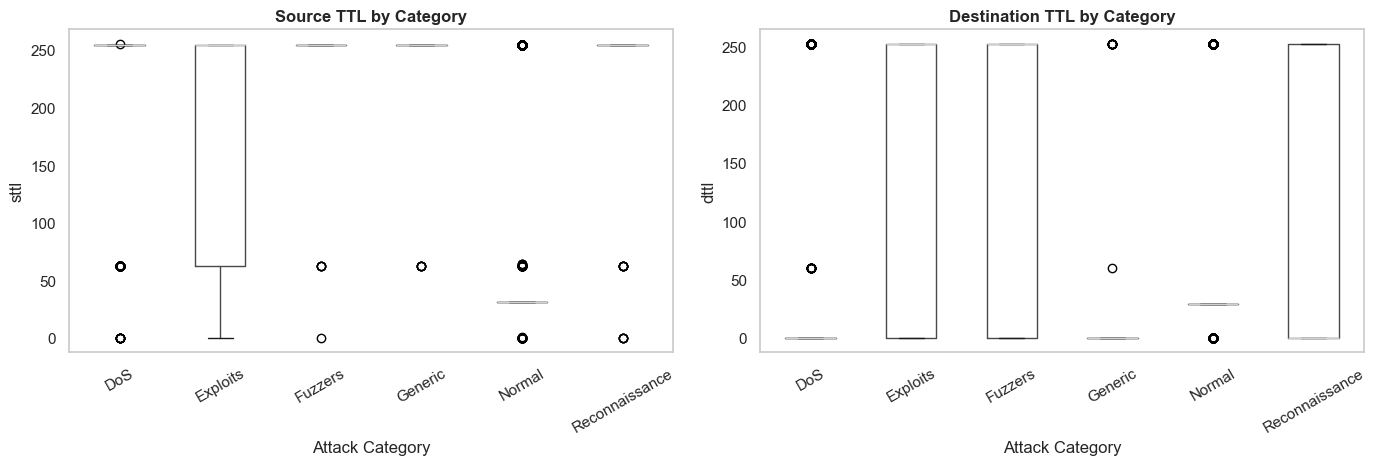

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='sttl', by='attack_cat', ax=axes[0], grid=False)
axes[0].set_title('Source TTL by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attack Category')
axes[0].set_ylabel('sttl')
plt.sca(axes[0])
plt.xticks(rotation=30)

df.boxplot(column='dttl', by='attack_cat', ax=axes[1], grid=False)
axes[1].set_title('Destination TTL by Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Attack Category')
axes[1].set_ylabel('dttl')
plt.sca(axes[1])
plt.xticks(rotation=30)

plt.suptitle('')
plt.tight_layout()
plt.savefig('plot_ttl_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Data Preprocessing

In [14]:
df_model = df.drop(columns=['id', 'attack_cat'], errors='ignore').copy()

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model.fillna(df_model.median(numeric_only=True), inplace=True)

X = df_model.drop(columns=['label'])
y = df_model['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)
print('Label distribution — Normal (0):', (y == 0).sum(), '| Attack (1):', (y == 1).sum())

Feature matrix shape: (6000, 42)
Label distribution — Normal (0): 1000 | Attack (1): 5000


## 7. Train / Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples :', X_train.shape[0])
print('Testing samples  :', X_test.shape[0])

Training samples : 4800
Testing samples  : 1200


## 8. Model 1 — Random Forest Classifier

### 8.1 Train and Evaluate

In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f'Random Forest — Accuracy: {acc_rf*100:.2f}%  |  AUC-ROC: {auc_rf:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attack']))

Random Forest — Accuracy: 96.50%  |  AUC-ROC: 0.9824

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.81      0.89       200
      Attack       0.96      0.99      0.98      1000

    accuracy                           0.96      1200
   macro avg       0.97      0.91      0.93      1200
weighted avg       0.97      0.96      0.96      1200



### 8.2 Confusion Matrix

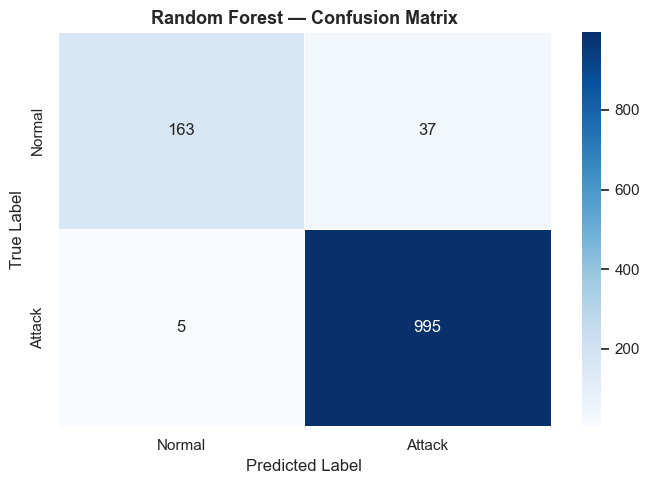

In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack'],
    ax=ax, linewidths=0.5
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('plot_rf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Feature Importance

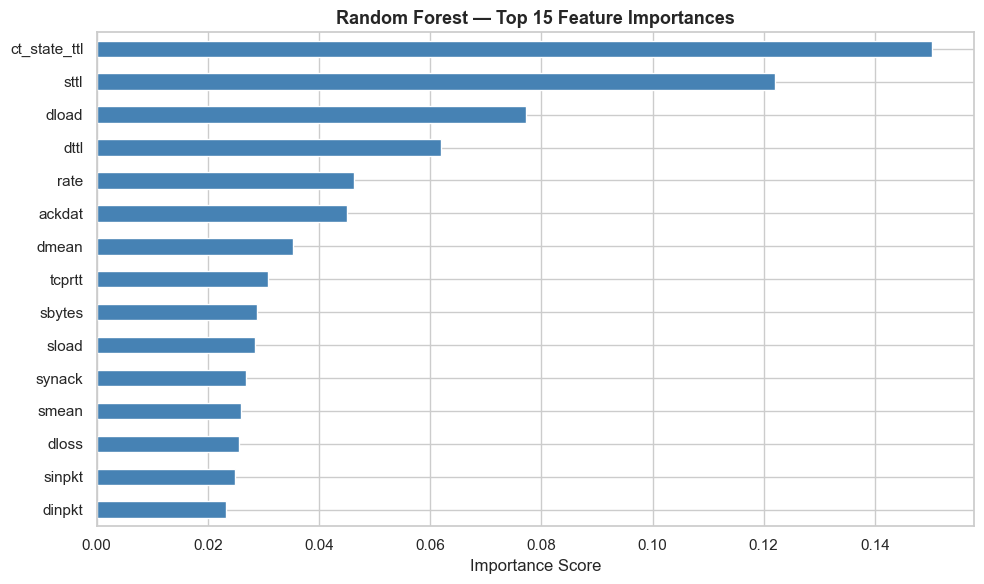

In [18]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Model 2 — Decision Tree Classifier

### 9.1 Train and Evaluate

In [19]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

print(f'Decision Tree — Accuracy: {acc_dt*100:.2f}%  |  AUC-ROC: {auc_dt:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=['Normal', 'Attack']))

Decision Tree — Accuracy: 95.50%  |  AUC-ROC: 0.9564

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.82      0.86       200
      Attack       0.97      0.98      0.97      1000

    accuracy                           0.95      1200
   macro avg       0.93      0.90      0.92      1200
weighted avg       0.95      0.95      0.95      1200



### 9.2 Confusion Matrix

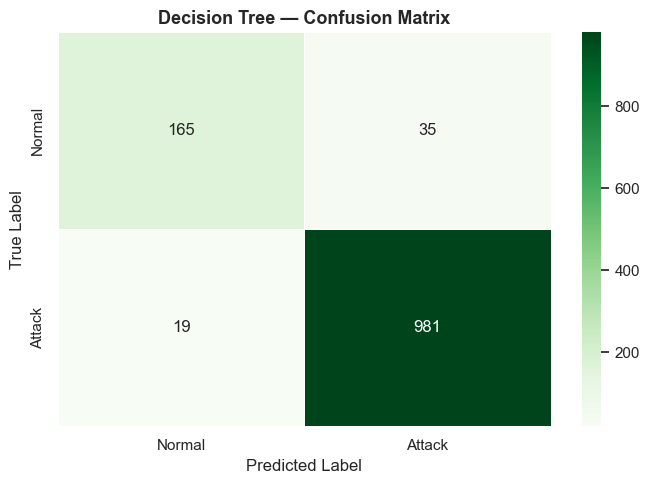

In [20]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_dt, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack'],
    ax=ax, linewidths=0.5
)
ax.set_title('Decision Tree — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('plot_dt_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Model 3 — Support Vector Machine (SVM)

### 10.1 Train and Evaluate

In [21]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, svm.predict_proba(X_test)[:, 1])

print(f'SVM — Accuracy: {acc_svm*100:.2f}%  |  AUC-ROC: {auc_svm:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=['Normal', 'Attack']))

SVM — Accuracy: 96.75%  |  AUC-ROC: 0.9651

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.81      0.89       200
      Attack       0.96      1.00      0.98      1000

    accuracy                           0.97      1200
   macro avg       0.98      0.90      0.94      1200
weighted avg       0.97      0.97      0.97      1200



### 10.2 Confusion Matrix

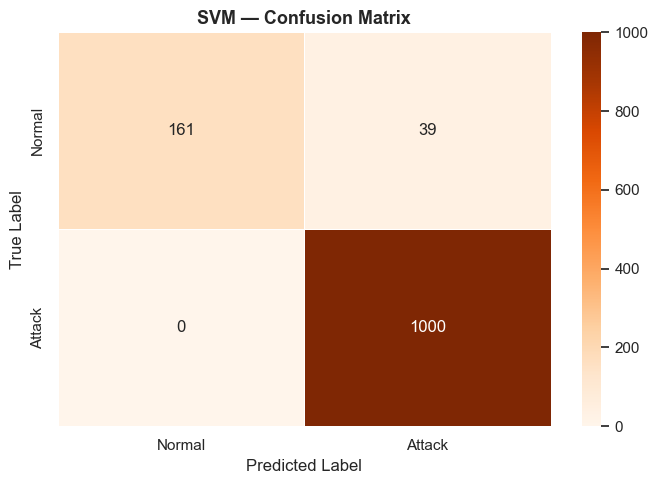

In [22]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_svm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack'],
    ax=ax, linewidths=0.5
)
ax.set_title('SVM — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('plot_svm_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. ROC Curve Comparison — All Models

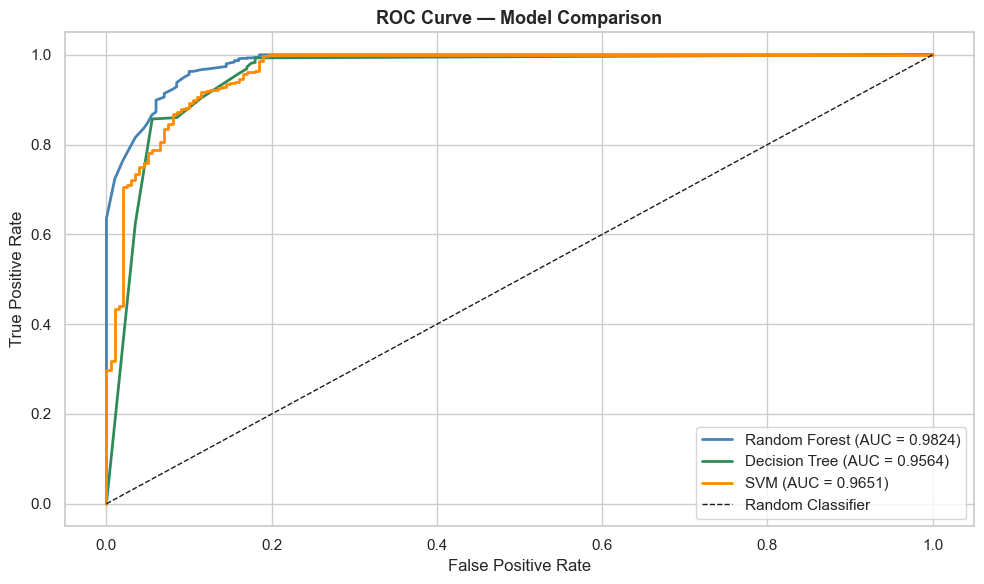

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

models = [
    ('Random Forest', rf, 'steelblue'),
    ('Decision Tree', dt, 'seagreen'),
    ('SVM',          svm, 'darkorange')
]

for name, model, color in models:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title('ROC Curve — Model Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Cross-Validation — 5-Fold

In [24]:
cv_results = {}

for name, model in [('Random Forest', rf), ('Decision Tree', dt), ('SVM', svm)]:
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:20s} | CV Mean: {scores.mean()*100:.2f}%  Std: {scores.std()*100:.2f}%')

Random Forest        | CV Mean: 89.17%  Std: 15.25%
Decision Tree        | CV Mean: 87.12%  Std: 16.77%
SVM                  | CV Mean: 94.73%  Std: 3.42%


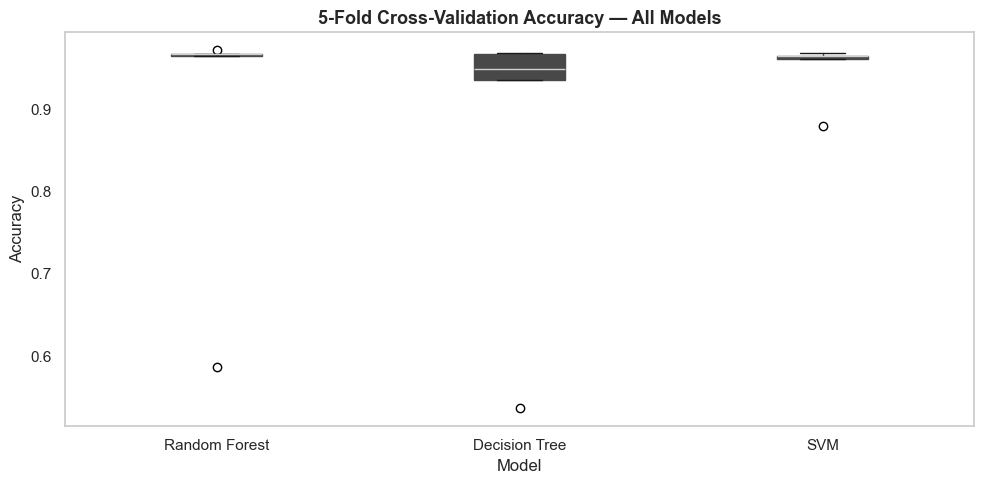

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, grid=False, patch_artist=True)
ax.set_title('5-Fold Cross-Validation Accuracy — All Models', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Model')
plt.tight_layout()
plt.savefig('plot_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Model Comparison Summary

In [26]:
summary = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree', 'SVM'],
    'Accuracy (%)': [
        round(acc_rf * 100, 2),
        round(acc_dt * 100, 2),
        round(acc_svm * 100, 2)
    ],
    'AUC-ROC': [
        round(auc_rf, 4),
        round(auc_dt, 4),
        round(auc_svm, 4)
    ],
    'CV Mean Accuracy (%)': [
        round(cv_results['Random Forest'].mean() * 100, 2),
        round(cv_results['Decision Tree'].mean() * 100, 2),
        round(cv_results['SVM'].mean() * 100, 2)
    ]
})

print(summary.to_string(index=False))

        Model  Accuracy (%)  AUC-ROC  CV Mean Accuracy (%)
Random Forest         96.50   0.9824                 89.17
Decision Tree         95.50   0.9564                 87.12
          SVM         96.75   0.9651                 94.73


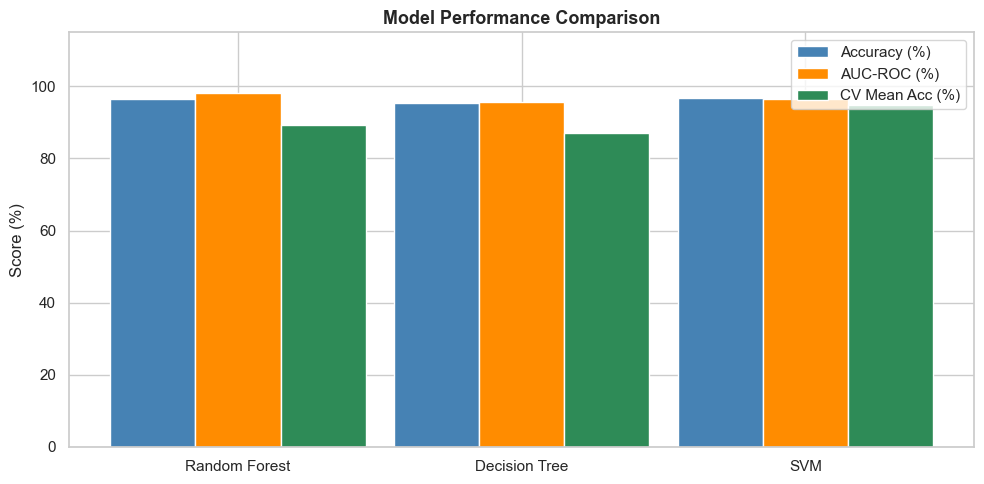

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(summary['Model']))
width = 0.3

ax.bar(x - width, summary['Accuracy (%)'], width, label='Accuracy (%)', color='steelblue', edgecolor='white')
ax.bar(x,         summary['AUC-ROC'] * 100, width, label='AUC-ROC (%)', color='darkorange', edgecolor='white')
ax.bar(x + width, summary['CV Mean Accuracy (%)'], width, label='CV Mean Acc (%)', color='seagreen', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(summary['Model'])
ax.set_ylim(0, 115)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Further Development Added After the Original Model Comparison



### 14.1 Additional Imports for Further Development

In [ ]:

import time
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, accuracy_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


def get_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

print('All further-development imports loaded successfully.')


All further-development imports loaded successfully.


### 14.2 Multi-Class Classification: Predicting Specific Attack Category


In [ ]:

df_multiclass = df.copy()


df_multiclass['attack_cat'] = df_multiclass['attack_cat'].fillna('').astype(str).str.strip()
df_multiclass.loc[df_multiclass['label'] == 0, 'attack_cat'] = 'Normal'
df_multiclass.loc[(df_multiclass['attack_cat'] == '') & (df_multiclass['label'] == 1), 'attack_cat'] = 'Unknown'


class_counts = df_multiclass['attack_cat'].value_counts()
valid_classes = class_counts[class_counts >= 4].index.tolist()
df_multiclass = df_multiclass[df_multiclass['attack_cat'].isin(valid_classes)].reset_index(drop=True)

X_multi_raw = df_multiclass.drop(columns=['id', 'label', 'attack_cat'], errors='ignore')
y_multi = df_multiclass['attack_cat']

numeric_features   = X_multi_raw.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_multi_raw.select_dtypes(include='object').columns.tolist()

multi_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', get_one_hot_encoder(), categorical_features)
    ],
    remainder='drop'
)

X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi_raw,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

print('Multi-class target distribution:')
print(y_multi.value_counts())
print(f'\nTraining shape : {X_multi_train.shape} | Testing shape: {X_multi_test.shape}')
print(f'Classes in train: {sorted(y_multi_train.unique())}')
print(f'Classes in test : {sorted(y_multi_test.unique())}')


Multi-class target distribution:
attack_cat
Normal            1000
DoS               1000
Exploits          1000
Reconnaissance    1000
Generic           1000
Fuzzers           1000
Name: count, dtype: int64

Training shape : (4800, 42) | Testing shape: (1200, 42)
Classes in train: ['DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance']
Classes in test : ['DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance']


In [ ]:

multiclass_models = {
    'Random Forest Multi-Class': Pipeline(steps=[
        ('preprocess', clone(multi_preprocessor)),
        ('model', RandomForestClassifier(
            n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced'))
    ]),
    'Decision Tree Multi-Class': Pipeline(steps=[
        ('preprocess', clone(multi_preprocessor)),
        ('model', DecisionTreeClassifier(
            max_depth=10, random_state=42, class_weight='balanced'))
    ]),
    'SVM Multi-Class': Pipeline(steps=[
        ('preprocess', clone(multi_preprocessor)),
        ('model', SVC(
            kernel='rbf', C=1.0, gamma='scale', probability=True,
            random_state=42, class_weight='balanced', max_iter=10000))
    ])
}

multiclass_results = []
multiclass_predictions = {}

for model_name, pipe in multiclass_models.items():
    print(f'Training {model_name}...')
    start_train = time.perf_counter()
    pipe.fit(X_multi_train, y_multi_train)
    train_time = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    y_multi_pred = pipe.predict(X_multi_test)
    pred_time = time.perf_counter() - start_pred

    accuracy    = accuracy_score(y_multi_test, y_multi_pred)
    macro_f1    = f1_score(y_multi_test, y_multi_pred, average='macro')
    weighted_f1 = f1_score(y_multi_test, y_multi_pred, average='weighted')
    balanced_acc = balanced_accuracy_score(y_multi_test, y_multi_pred)
    latency_ms  = (pred_time / len(X_multi_test)) * 1000

    multiclass_predictions[model_name] = y_multi_pred
    multiclass_results.append({
        'Model': model_name,
        'Accuracy (%)': round(accuracy * 100, 2),
        'Balanced Accuracy (%)': round(balanced_acc * 100, 2),
        'Macro F1 (%)': round(macro_f1 * 100, 2),
        'Weighted F1 (%)': round(weighted_f1 * 100, 2),
        'Training Time (s)': round(train_time, 3),
        'Inference Latency (ms/record)': round(latency_ms, 4)
    })

    print('\n' + '='*80)
    print(model_name)
    print('='*80)
    print(classification_report(y_multi_test, y_multi_pred))

multiclass_summary = pd.DataFrame(multiclass_results)
multiclass_summary


Training Random Forest Multi-Class...

Random Forest Multi-Class
                precision    recall  f1-score   support

           DoS       0.55      0.58      0.57       200
      Exploits       0.62      0.56      0.59       200
       Fuzzers       0.75      0.91      0.82       200
       Generic       0.98      0.97      0.98       200
        Normal       0.98      0.84      0.91       200
Reconnaissance       0.85      0.81      0.83       200

      accuracy                           0.78      1200
     macro avg       0.79      0.78      0.78      1200
  weighted avg       0.79      0.78      0.78      1200

Training Decision Tree Multi-Class...

Decision Tree Multi-Class
                precision    recall  f1-score   support

           DoS       0.53      0.79      0.64       200
      Exploits       0.70      0.45      0.55       200
       Fuzzers       0.76      0.90      0.82       200
       Generic       1.00      0.97      0.98       200
        Normal       0.97 

,Model,Accuracy (%),Balanced Accuracy (%),Macro F1 (%),Weighted F1 (%),Training Time (s),Inference Latency (ms/record)
0,Random Forest Multi-Class,78.00,78.00,78.09,78.09,0.300,0.0275
1,Decision Tree Multi-Class,78.42,78.42,78.47,78.47,0.063,0.0029
2,SVM Multi-Class,74.75,74.75,74.64,74.64,3.619,0.2393


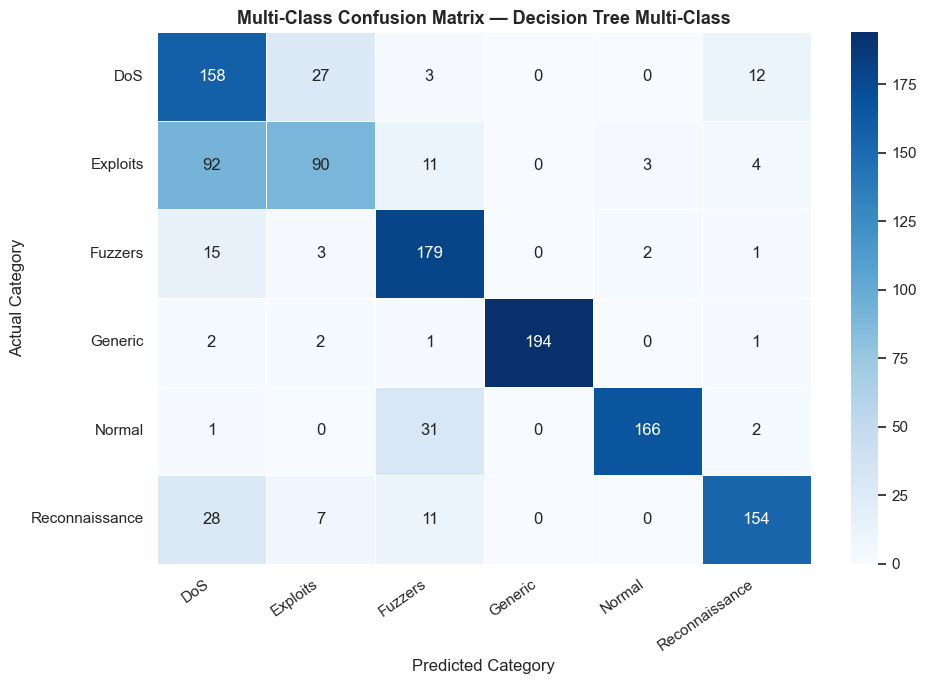

In [ ]:

best_multiclass_model_name = multiclass_summary.sort_values('Macro F1 (%)', ascending=False).iloc[0]['Model']
best_multiclass_predictions = multiclass_predictions[best_multiclass_model_name]
class_labels = sorted(y_multi.unique())

cm_multi = confusion_matrix(y_multi_test, best_multiclass_predictions, labels=class_labels)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    ax=ax
)
ax.set_title(f'Multi-Class Confusion Matrix — {best_multiclass_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Category')
ax.set_ylabel('Actual Category')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_multiclass_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.3 Hyperparameter Optimisation with GridSearchCV



In [ ]:

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced']
}

svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

svm_grid = GridSearchCV(
    estimator=SVC(probability=True, random_state=42, max_iter=10000),
    param_grid=svm_param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

print('Tuning Random Forest ...')
rf_grid.fit(X_train, y_train)

print('\nTuning SVM ...')
svm_grid.fit(X_train, y_train)

print('\nBest Random Forest parameters:', rf_grid.best_params_)
print('Best RF CV F1 :', round(rf_grid.best_score_, 4))
print('\nBest SVM parameters:', svm_grid.best_params_)
print('Best SVM CV F1 :', round(svm_grid.best_score_, 4))


Tuning Random Forest ...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Tuning SVM ...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Random Forest parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best RF CV F1 : 0.9809

Best SVM parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV F1 : 0.9799


In [ ]:

tuned_models = {
    'Original Random Forest': rf,
    'Tuned Random Forest': rf_grid.best_estimator_,
    'Original SVM': svm,
    'Tuned SVM': svm_grid.best_estimator_
}

tuned_summary_rows = []
for model_name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    tuned_summary_rows.append({
        'Model': model_name,
        'Accuracy (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'F1 Attack (%)': round(f1_score(y_test, y_pred) * 100, 2),
        'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4),
        'False Negatives': cm[1, 0],
        'False Positives': cm[0, 1]
    })

tuned_summary = pd.DataFrame(tuned_summary_rows)
tuned_summary


,Model,Accuracy (%),F1 Attack (%),AUC-ROC,False Negatives,False Positives
0,Original Random Forest,96.50,97.93,0.9824,5,37
1,Tuned Random Forest,96.83,98.13,0.9828,1,37
2,Original SVM,96.75,98.09,0.9651,0,39
3,Tuned SVM,96.67,98.04,0.9587,2,38


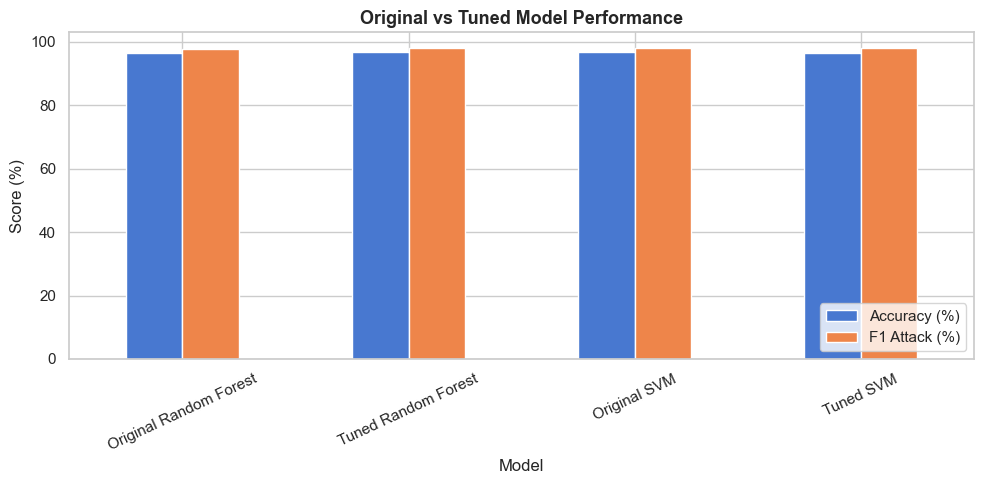

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = tuned_summary.set_index('Model')[['Accuracy (%)', 'F1 Attack (%)']]
plot_df.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Original vs Tuned Model Performance', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_original_vs_tuned_models.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.4 Explainability: Model Interpretation for SOC Analysts



In [ ]:

best_binary_model_name = tuned_summary.sort_values('F1 Attack (%)', ascending=False).iloc[0]['Model']
best_binary_model = tuned_models[best_binary_model_name]

print('Explaining model:', best_binary_model_name)

perm_result = permutation_importance(
    best_binary_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

perm_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance Mean': perm_result.importances_mean,
    'Importance Std': perm_result.importances_std
}).sort_values('Importance Mean', ascending=False)

perm_importance.head(15)

Explaining model: Tuned Random Forest


,Feature,Importance Mean,Importance Std
9,sttl,0.001071,0.000367
33,ct_src_dport_ltm,0.000385,0.000193
19,swin,0.000200,0.000245
11,sload,0.000193,0.000236
13,sloss,0.000104,0.000199
27,dmean,0.000100,0.000200
34,ct_dst_sport_ltm,0.000096,0.000193
40,ct_srv_dst,0.000089,0.000481
35,ct_dst_src_ltm,0.000089,0.000481
24,synack,0.000000,0.000000


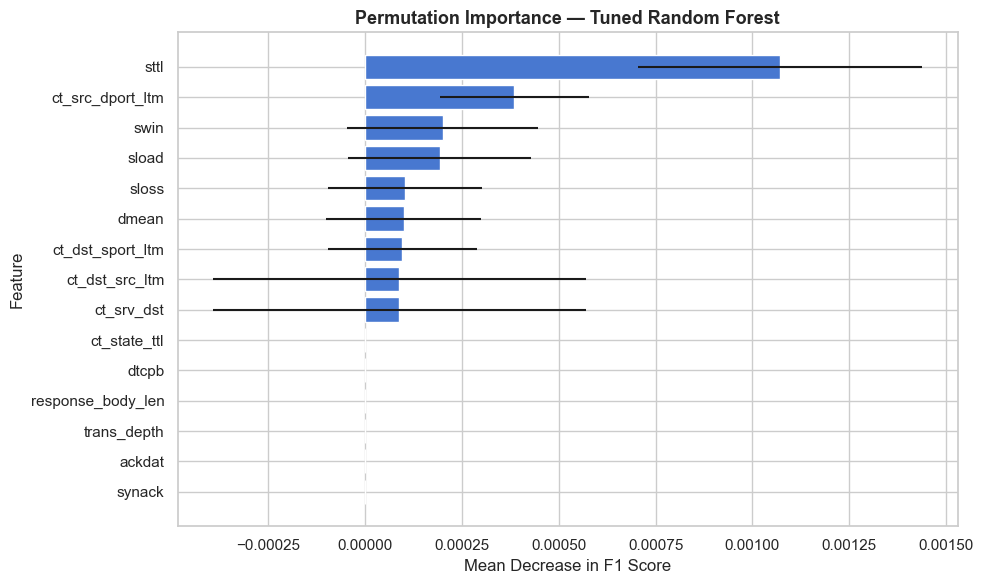

In [36]:
top_perm = perm_importance.head(15).sort_values('Importance Mean')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_perm['Feature'], top_perm['Importance Mean'], xerr=top_perm['Importance Std'], edgecolor='white')
ax.set_title(f'Permutation Importance — {best_binary_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in F1 Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('plot_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

SHAP Summary Plot — Attack Class Feature Impact


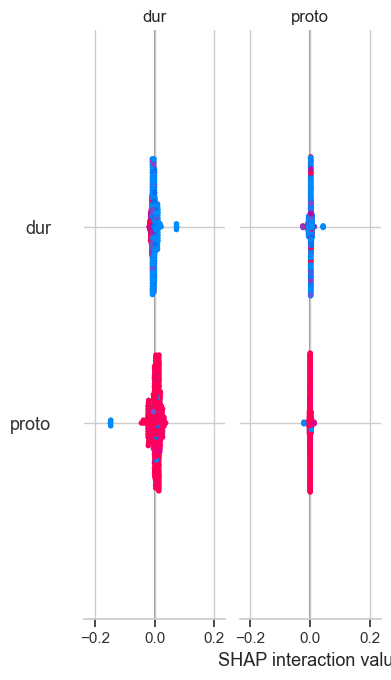

In [ ]:

try:
    import shap

    if isinstance(best_binary_model, RandomForestClassifier):
        sample_size = min(500, X_test.shape[0])
        X_shap = pd.DataFrame(X_test[:sample_size], columns=X.columns)
        explainer = shap.TreeExplainer(best_binary_model)
        shap_values = explainer.shap_values(X_shap)


        if isinstance(shap_values, list) and len(shap_values) == 2:
            shap_vals_plot = shap_values[1]
        else:
            shap_vals_plot = shap_values

        print('SHAP Summary Plot — Attack Class Feature Impact')
        shap.summary_plot(shap_vals_plot, X_shap, feature_names=X.columns.tolist(), show=True)
    else:
        print('SHAP TreeExplainer requires a tree-based model.')
        print(f'Selected best model ({best_binary_model_name}) is not a Random Forest.')
        print('Permutation importance above has already provided model-agnostic explainability.')
except ImportError:
    print('SHAP is not installed. To enable SHAP, run: pip install shap')
    print('Permutation importance has been used as a reliable built-in explainability method.')
except Exception as e:
    print(f'SHAP encountered an error: {e}')
    print('Permutation importance above remains valid for explainability.')


### 14.5 Real-Time / Deployment Readiness



In [ ]:

X_binary_raw = df.drop(columns=['id', 'label', 'attack_cat'], errors='ignore')
y_binary = df['label']

binary_numeric_features    = X_binary_raw.select_dtypes(include=np.number).columns.tolist()
binary_categorical_features = X_binary_raw.select_dtypes(include='object').columns.tolist()

binary_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), binary_numeric_features),
        ('cat', get_one_hot_encoder(), binary_categorical_features)
    ],
    remainder='drop'
)

X_bin_train_raw, X_bin_test_raw, y_bin_train, y_bin_test = train_test_split(
    X_binary_raw, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)


try:
    best_kernel = svm_grid.best_params_.get('kernel', 'rbf')
    best_C      = svm_grid.best_params_.get('C', 1)
    best_gamma  = svm_grid.best_params_.get('gamma', 'scale')
except Exception:
    best_kernel, best_C, best_gamma = 'rbf', 1, 'scale'

binary_deployment_pipeline = Pipeline(steps=[
    ('preprocess', binary_preprocessor),
    ('model', SVC(
        kernel=best_kernel, C=best_C, gamma=best_gamma,
        probability=True, random_state=42,
        class_weight='balanced', max_iter=10000
    ))
])

binary_deployment_pipeline.fit(X_bin_train_raw, y_bin_train)

deploy_pred = binary_deployment_pipeline.predict(X_bin_test_raw)
deploy_prob = binary_deployment_pipeline.predict_proba(X_bin_test_raw)[:, 1]

print('Deployment Pipeline Results')
print('Accuracy :', round(accuracy_score(y_bin_test, deploy_pred) * 100, 2), '%')
print('F1 Attack:', round(f1_score(y_bin_test, deploy_pred) * 100, 2), '%')
print('AUC-ROC  :', round(roc_auc_score(y_bin_test, deploy_prob), 4))
print('\nClassification Report:')
print(classification_report(y_bin_test, deploy_pred, target_names=['Normal', 'Attack']))


Deployment Pipeline Results
Accuracy : 94.33 %
F1 Attack: 96.57 %
AUC-ROC  : 0.9692

Classification Report:
              precision    recall  f1-score   support

      Normal       0.81      0.87      0.84       200
      Attack       0.97      0.96      0.97      1000

    accuracy                           0.94      1200
   macro avg       0.89      0.91      0.90      1200
weighted avg       0.95      0.94      0.94      1200



In [ ]:

sample_records = X_bin_test_raw.head(min(1000, len(X_bin_test_raw)))

start_time = time.perf_counter()
_ = binary_deployment_pipeline.predict(sample_records)
elapsed_time = time.perf_counter() - start_time

latency_per_record_ms = (elapsed_time / len(sample_records)) * 1000
throughput_records_per_second = len(sample_records) / elapsed_time if elapsed_time > 0 else np.inf

print(f'Latency per record: {latency_per_record_ms:.4f} ms')
print(f'Throughput: {throughput_records_per_second:.2f} records/second')

Latency per record: 0.0740 ms
Throughput: 13518.96 records/second


In [ ]:
def predict_traffic_status(new_records: pd.DataFrame) -> pd.DataFrame:
    """
    Predict whether new raw UNSW-NB15 records are Normal or Attack.
    The input dataframe should contain the same feature columns used in training.
    """
    required_columns = X_binary_raw.columns.tolist()
    missing_columns = [col for col in required_columns if col not in new_records.columns]

    if missing_columns:
        raise ValueError(f'Missing required columns: {missing_columns}')

    new_records = new_records[required_columns].copy()
    predictions = binary_deployment_pipeline.predict(new_records)
    probabilities = binary_deployment_pipeline.predict_proba(new_records)[:, 1]

    return pd.DataFrame({
        'Predicted_Label': np.where(predictions == 1, 'Attack', 'Normal'),
        'Attack_Probability': probabilities.round(4)
    })

predict_traffic_status(X_bin_test_raw.head(5))

,Predicted_Label,Attack_Probability
0,Attack,1.0000
1,Attack,1.0000
2,Normal,0.1035
3,Normal,0.0009
4,Normal,0.0480


In [ ]:

model_package = {
    'pipeline': binary_deployment_pipeline,
    'feature_columns': X_binary_raw.columns.tolist(),
    'class_mapping': {0: 'Normal', 1: 'Attack'},
    'notes': 'Deployment-ready binary anomaly detection pipeline using preprocessing + SVM classifier.'
}

joblib.dump(model_package, 'unsw_nb15_binary_deployment_pipeline.joblib')
print('Saved model package: unsw_nb15_binary_deployment_pipeline.joblib')

Saved model package: unsw_nb15_binary_deployment_pipeline.joblib
